## **SmartVisa: An Intelligent System for Predicting US Visa Approvals.**


### **Project Life Cycle**

![Description](https://media.licdn.com/dms/image/v2/D4E12AQF-GBbSSMoDbg/article-cover_image-shrink_720_1280/article-cover_image-shrink_720_1280/0/1722609771232?e=1737590400&v=beta&t=1PtfJ8w_O8cDPtBMCoMyi9oJECNEQSJIc6tKsGGKA4Y)


## **About**
The United States allows foreign workers to enter the country for employment on a temporary or permanent basis under specific legal provisions. These regulations aim to balance workforce needs by addressing labor shortages while safeguarding domestic workers from potential adverse impacts. The programs overseeing foreign labor certification are managed by the Office of Foreign Labor Certification (OFLC).  




### **Problem Statement**  

- The OFLC processes job certification applications for employers seeking to employ foreign workers in the United States and decides on their certification status.  
- Due to a significant increase in applications last year, the OFLC requires a machine learning solution to streamline the visa approval process by analyzing historical data.

**This project aims to develop a classification model that will:**  
- Predict whether a visa application will be approved or denied based on historical data.  
- Assist in identifying suitable profiles by evaluating key factors influencing visa approval decisions.  

The model will provide insights that help recommend which applicants meet the necessary criteria for certification, improving the efficiency and fairness of the decision-making process.  


##  **Data Collection.**
* The Dataset is part of Office of Foreign Labor Certification (OFLC)
* The data consists of 25480 Rows and 12 Columns

###  Importing the  Required Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

**Importing the CSV Data as Pandas DataFrame**

In [8]:
df=pd.read_csv(r'usa_visadataset.csv')

**Show Top 5 Records**

In [9]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


**Show Bottom 5 Records**

In [10]:
df.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


**Showing 5 Random Records**

In [11]:
df.sample(5)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
8106,EZYV8107,Asia,Bachelor's,N,N,2213,2007,West,68995.32,Year,Y,Certified
305,EZYV306,North America,Master's,Y,N,48369,2007,West,53304.04,Year,Y,Certified
17955,EZYV17956,Asia,Master's,N,Y,564,1920,South,4575.97,Year,Y,Certified
19371,EZYV19372,Asia,Master's,Y,N,114,2008,West,287191.20,Year,Y,Certified
7694,EZYV7695,Asia,Bachelor's,N,N,2987,1883,South,50690.81,Year,Y,Certified


**Shape of the dataset**

In [12]:
df.shape

(25480, 12)

**Summary of the dataset**

In [13]:
# Display summary statistics of the dataframe
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


**Checking the Datatypes in the dataset**

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


**Checking Missing Values in the dataset**

In [15]:
df.isnull().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

There is no missing values in the dataset.

##  **Exploring The Data**

In [16]:
Numeric_features=[column for column in df.columns if df[column].dtype!='O']

Categorical_features=[column for column in df.columns if df[column].dtype=='O']

print(f"Number of Numerical Features: {len(Numeric_features)}")
print(f"Numerical Features are : {Numeric_features}")
print(f"Number of Categorical Features: {len(Categorical_features)}")
print(f"Categorical Features are : {Categorical_features}")

Number of Numerical Features: 3
Numerical Features are : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']
Number of Categorical Features: 9
Categorical Features are : ['case_id', 'continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


In [17]:
# proportion of count of data values in each categorical column
for column in Categorical_features:
    print(df[column].value_counts(normalize=True) * 100)
    print('---------------------------')

case_id
EZYV25480    0.003925
EZYV01       0.003925
EZYV02       0.003925
EZYV03       0.003925
EZYV04       0.003925
               ...   
EZYV13       0.003925
EZYV12       0.003925
EZYV11       0.003925
EZYV10       0.003925
EZYV09       0.003925
Name: proportion, Length: 25480, dtype: float64
---------------------------
continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64
---------------------------
education_of_employee
Bachelor's     40.164835
Master's       37.810047
High School    13.422292
Doctorate       8.602826
Name: proportion, dtype: float64
---------------------------
has_job_experience
Y    58.092622
N    41.907378
Name: proportion, dtype: float64
---------------------------
requires_job_training
N    88.402669
Y    11.597331
Name: proportion, dtype: float64
---------------------------
region_of_employment
Northeast    2

### **Insights**
- **`case_id`**: This column has unique values for each entry and does not provide any meaningful information for analysis. It can be dropped.  
- **`continent`**: The data is highly biased towards Asia. Other categories can be combined into a single category to simplify the analysis.  
- **`unit_of_wage`**: This column appears to be significant since most of the contracts are yearly, indicating its importance for predictions.



## **Univariate Analysis-Numerical Feature**

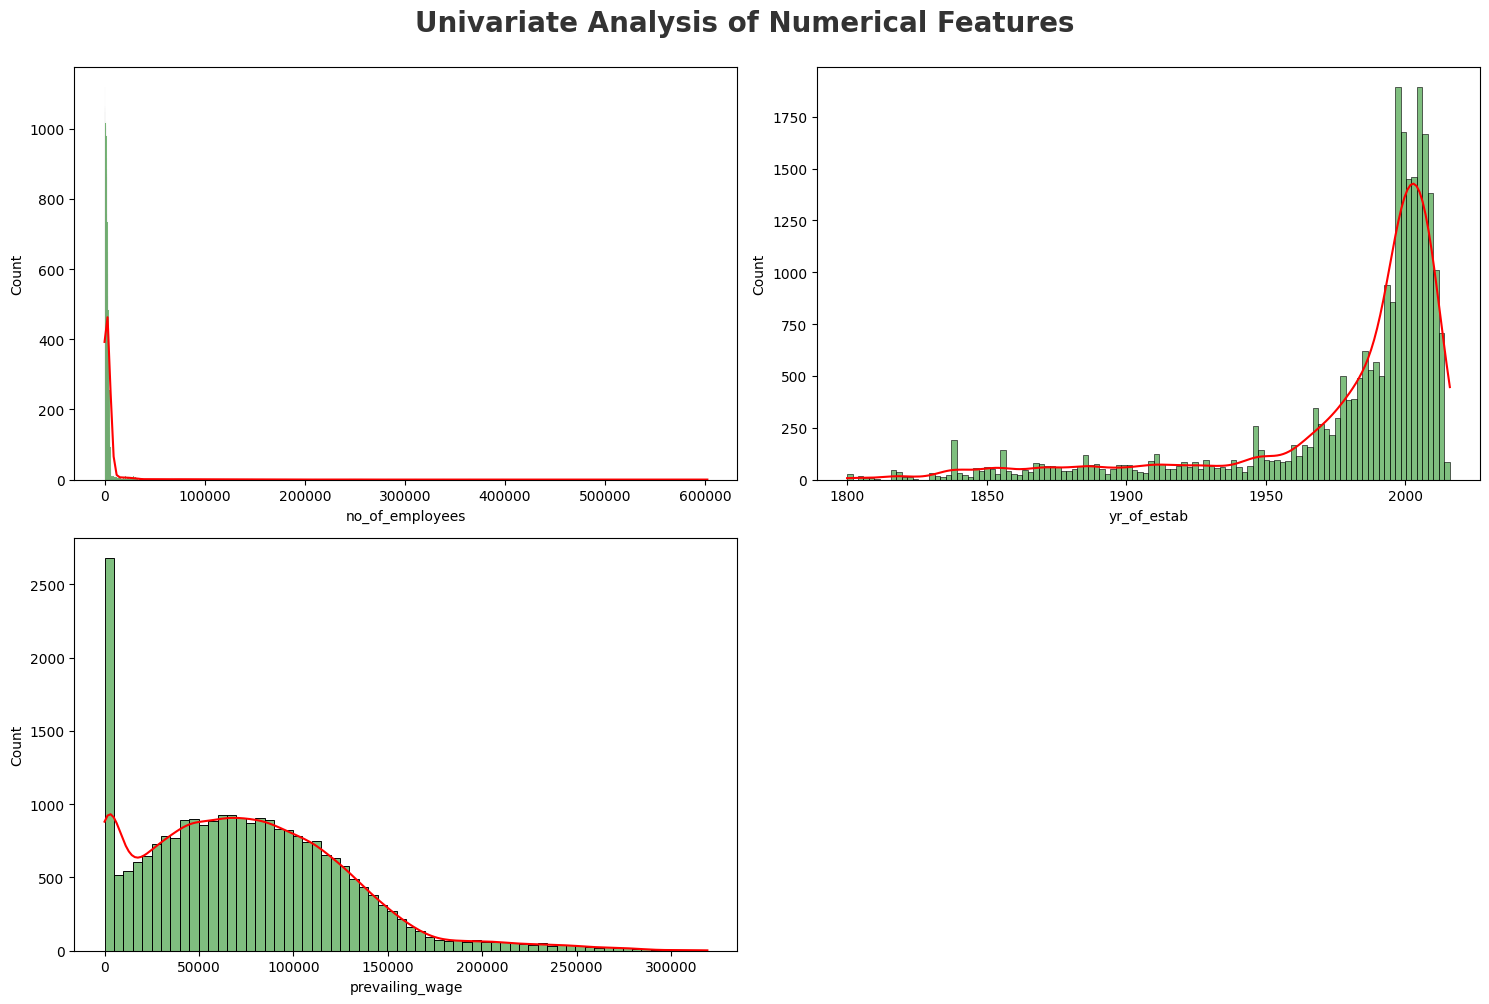

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(Numeric_features)):
    plt.subplot(2, 2, i+1)
    sns.histplot(x=df[Numeric_features[i]], color='Green', kde=True)
    plt.xlabel(Numeric_features[i])
    
    # Customizing KDE color after plotting
    kde_curve = plt.gca().lines[-1]  # Get the most recent line (KDE curve)
    kde_curve.set_color('Red')  # Change its color to red

    plt.tight_layout()

# save plot
# plt.savefig('./images/Univariate_Num.png')


# Insights 

 **`No. of Employees`**:

- The distribution is highly skewed to the right, indicating that most businesses have a relatively small number of employees.
- A few companies have an unusually large number of employees, making them outliers in the dataset.

 **`Year of Establishment (yr_of_estab)`**:

- The majority of companies were established after the 1950s, with a significant increase observed in recent decades.
- This trend may reflect industrialization and modernization trends in recent years.

 **`Prevailing Wage`**:


- The distribution is also heavily right-skewed, with most wages concentrated in the lower range.
- A small number of applications show exceptionally high wages, which could represent senior-level or specialized roles.


### **Univariate Analysis-Categorical Feature**

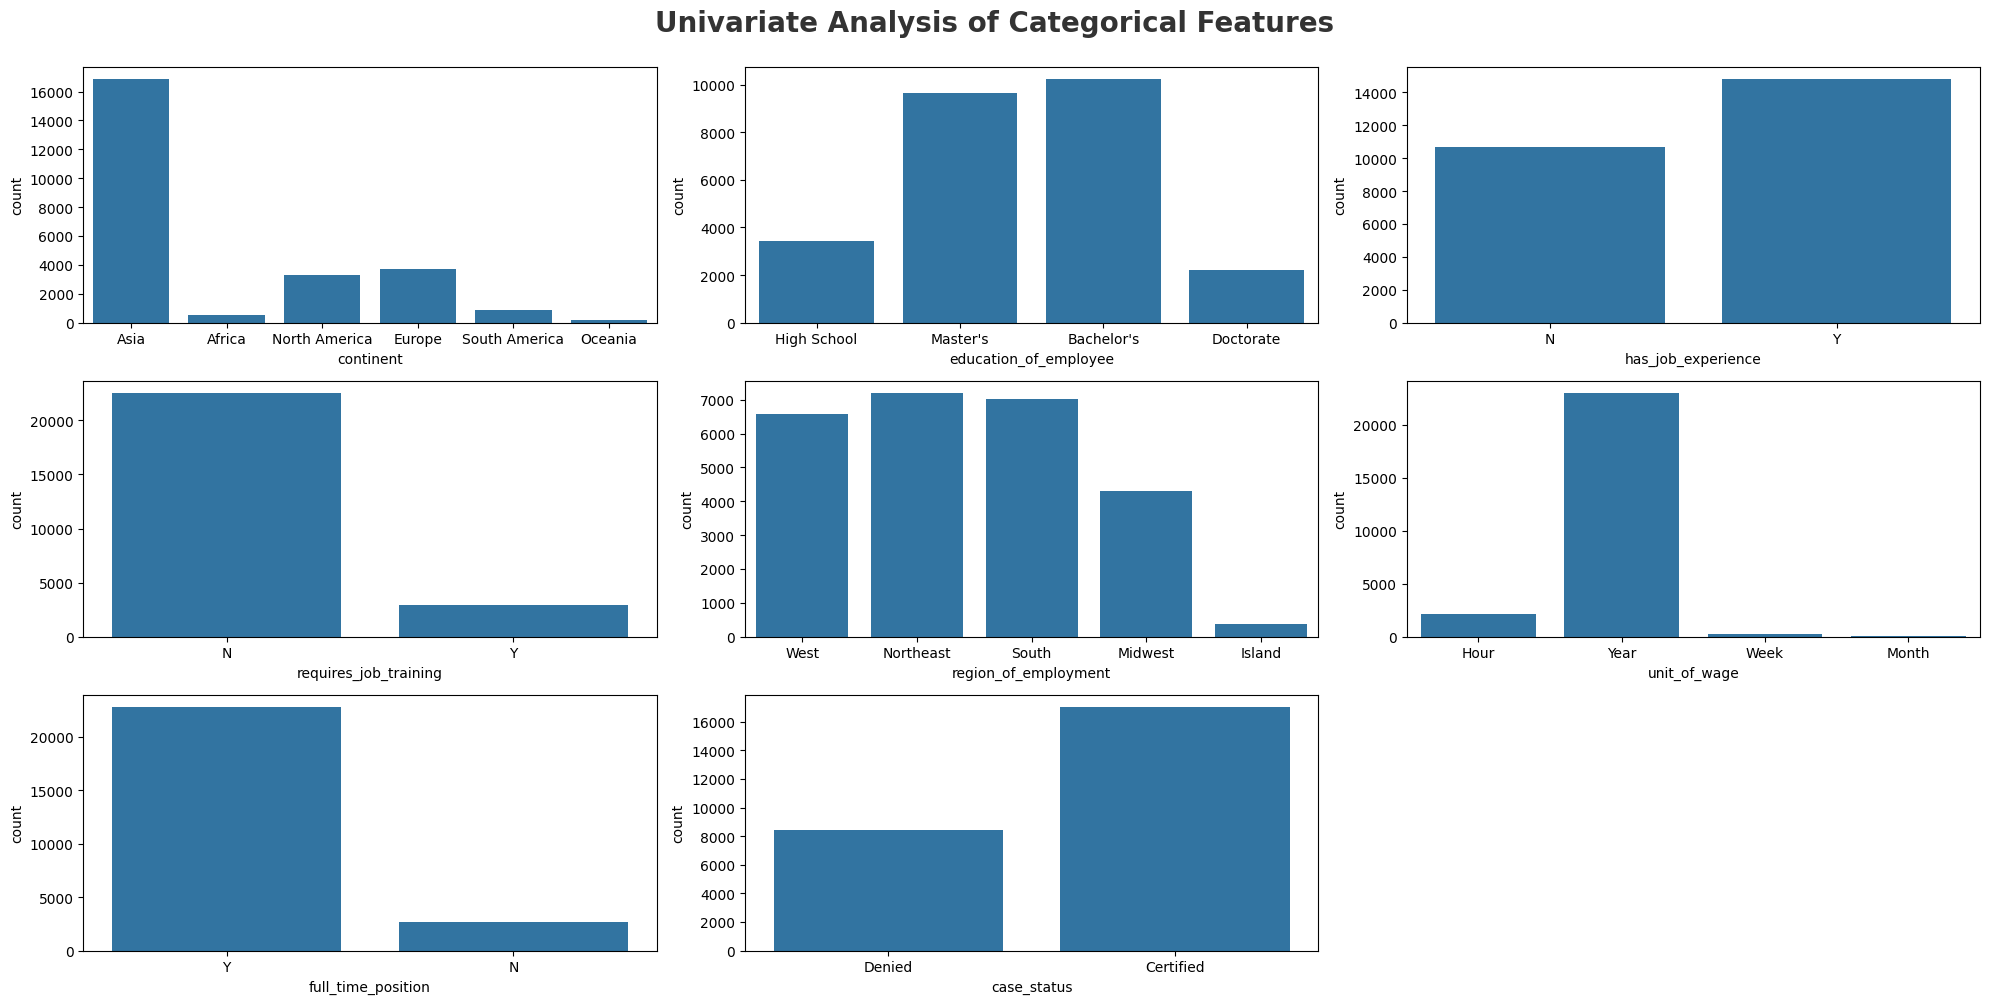

In [20]:
# categorical columns
#Categorical_features.remove('case_id')
plt.figure(figsize=(20, 10))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(Categorical_features)):
    plt.subplot(3, 3, i+1)
    sns.countplot(x=df[Categorical_features[i]])
    plt.xlabel(Categorical_features[i])
    plt.tight_layout()
    
# save plot
# plt.savefig('./images/Univariate_Cat.png')

### Insights

1. **Geographical Concentration**: There is a significant geographical concentration in Asia, highlighting a regional dominance in the dataset.
2. **Educational Background**: A majority of candidates hold higher education degrees, with Bachelor's and Master's degrees being the most prevalent.
3. **Experience Preference**: The dataset shows a clear preference for candidates with substantial work experience.
4. **Employment Type**: The majority of positions are full-time, indicating a stable employment trend.
5. **Certification Rate**: A high percentage of candidates possess relevant certifications, demonstrating the importance of specialized qualifications.
6. **Wage Structure**: The annual wage structure is the most common, suggesting its widespread adoption across industries.


### **Multivariate Analysis**

In [21]:
discrete_features=[feature for feature in Numeric_features if len(df[feature].unique())<=25]

continuous_features=[feature for feature in Numeric_features if len(df[feature].unique()) > 25]

print(f'We have {len(discrete_features)} discrete features : {discrete_features}')
print(f'\nWe have {len(continuous_features)} continuous_features : {continuous_features}')

We have 0 discrete features : []

We have 3 continuous_features : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


### **Checking the Multicollinearity in Numerical features**

In [33]:
df[Numeric_features].corr()

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


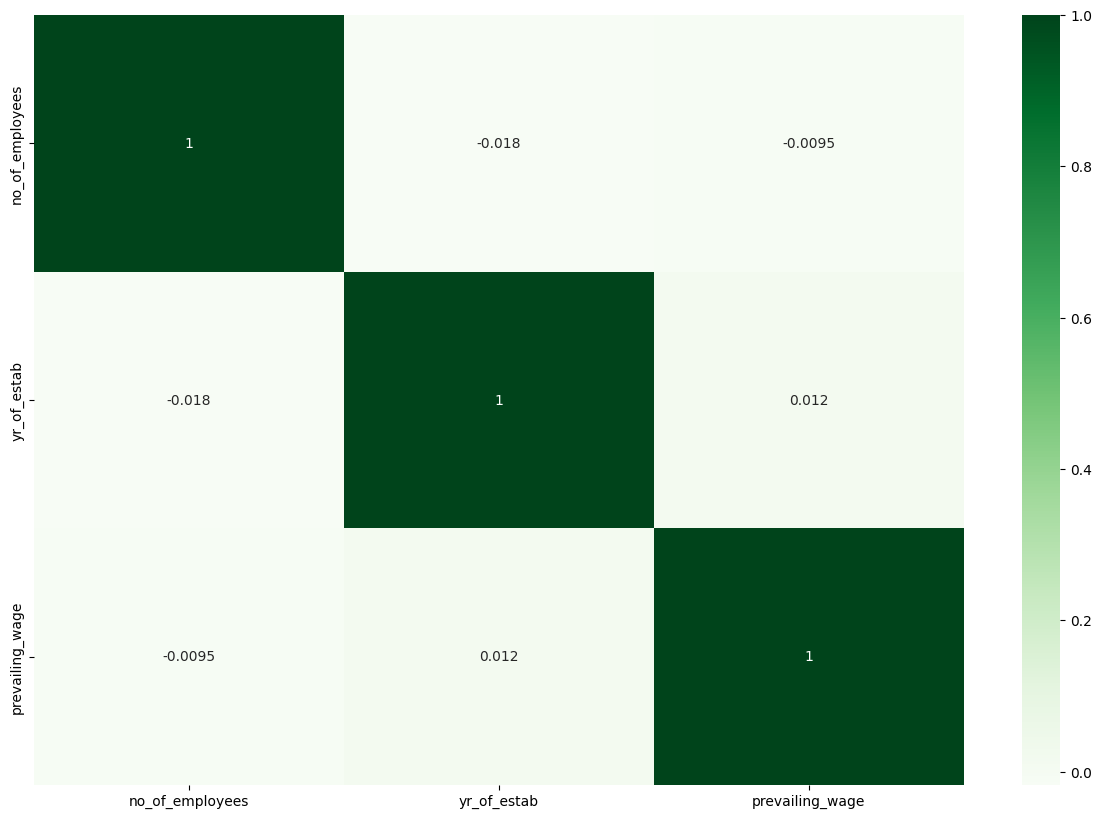

In [37]:
df1=df.copy()
plt.figure(figsize = (15,10))
sns.heatmap(df[Numeric_features].corr(), cmap="Greens", annot=True)
plt.show()

### Insights from the Correlation Matrix

- **No. of Employees**:
  - Has a **perfect correlation (1.000)** with itself, as expected.
  - Shows a **weak negative correlation (-0.017770)** with the year of establishment (`yr_of_estab`), indicating that the number of employees is not significantly influenced by the establishment year.
  - Exhibits a **very weak negative correlation (-0.009523)** with prevailing wage, suggesting minimal or no relationship.

- **Year of Establishment (`yr_of_estab`)**:
  - Displays a **weak positive correlation (0.012342)** with prevailing wage, implying a slight tendency for newer companies to offer higher wages, though the relationship is negligible.

- **Prevailing Wage**:
  - Shows **minimal correlation with both other features** (`no_of_employees`: -0.009523, `yr_of_estab`: 0.012342), indicating that wages are not strongly linked to the number of employees or the establishment year.

### Key Takeaways
- The correlations between the features are extremely weak, indicating **no strong linear relationships**.
- This suggests that each feature captures largely independent information, which can be useful for modeling without significant concerns of multicollinearity.


### **Checking the Multicollinearity in Categorical features**

#### **Hypothesis Testing for Categorical Variables**

Hypothesis testing, such as the **Chi-Square test of independence**, is used to evaluate whether two categorical variables are significantly associated or independent. It is particularly useful for assessing the correlation or dependency between categorical variables because:

---

#### Nature of Categorical Data
- **Categorical Data** represents groupings or categories (e.g., `case_status`, `gender`), where traditional correlation measures (like Pearson's correlation) are not applicable.
- The **Chi-Square test** examines the relationship between categories using contingency tables.

---

#### Hypothesis Testing Framework
1. **Null Hypothesis (H₀)**: The variables are independent (no association).
2. **Alternative Hypothesis (H₁)**: The variables are dependent (there is an association).

- The **p-value** determines whether to reject the null hypothesis:
- If the p-value is less than a chosen significance level (commonly 0.05), it suggests a significant association between the variables.


In [40]:
from scipy.stats import chi2_contingency
chi2_test = []
for feature in Categorical_features:
    if chi2_contingency(pd.crosstab(df['case_status'], df[feature]))[1] < 0.05:
        chi2_test.append('Reject Null Hypothesis')
    else:
        chi2_test.append('Fail to Reject Null Hypothesis')
result = pd.DataFrame(data=[Categorical_features, chi2_test]).T
result.columns = ['Column', 'Hypothesis Result']
result

,Column,Hypothesis Result
0,continent,Reject Null Hypothesis
1,education_of_employee,Reject Null Hypothesis
2,has_job_experience,Reject Null Hypothesis
3,requires_job_training,Fail to Reject Null Hypothesis
4,region_of_employment,Reject Null Hypothesis
5,unit_of_wage,Reject Null Hypothesis
6,full_time_position,Reject Null Hypothesis
7,case_status,Reject Null Hypothesis


### Insights from Hypothesis Testing Results

The hypothesis testing results provide a clear picture of which categorical variables are significantly associated with the target variable. Here are the insights:

---

#### **Significant Associations (Reject Null Hypothesis)**:
1. **Continent**:
   - There is a significant relationship between the continent of the employee and the target variable. Geographic factors might influence trends like visa approvals or employment opportunities.

2. **Education of Employee**:
   - Employee education level is significantly associated with the target. Higher education may increase the likelihood of achieving desired outcomes, such as job offers or visa approvals.

3. **Has Job Experience**:
   - Prior job experience significantly impacts the target variable. Experienced candidates may be more favorable for approvals or specific employment types.

4. **Region of Employment**:
   - The region where employment is located shows a significant association. This may reflect regional hiring preferences or labor market conditions.

5. **Unit of Wage**:
   - The wage structure (e.g., hourly, yearly) is significantly linked to the target. This could indicate preferences for specific wage types in certain job applications.

6. **Full-Time Position**:
   - Full-time employment status has a strong association with the target. Employers might prefer full-time roles over part-time roles for certain positions.

7. **Case Status**:
   - The outcome of the case (e.g., approval or denial) is significantly related to other factors, as expected.

---

#### **No Significant Association (Fail to Reject Null Hypothesis)**:
1. **Requires Job Training**:
   - Job training requirements do not show a significant association with the target. This might suggest that training is not a critical factor in determining outcomes like approvals or employment.

---

### Overall Implications:
- The majority of variables are significantly associated with the target variable, indicating their potential importance in predictive modeling or decision-making.
- **Requires Job Training** stands out as the only variable with no significant relationship, suggesting it may have limited impact and could be excluded or given lower priority during feature selection.




In [60]:
continuous_numerical_features=[feature for feature in Numeric_features if len(df[feature].unique())>=10]
print(f"Continuous_numerical_features are : {continuous_numerical_features}")

Continuous_numerical_features are : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


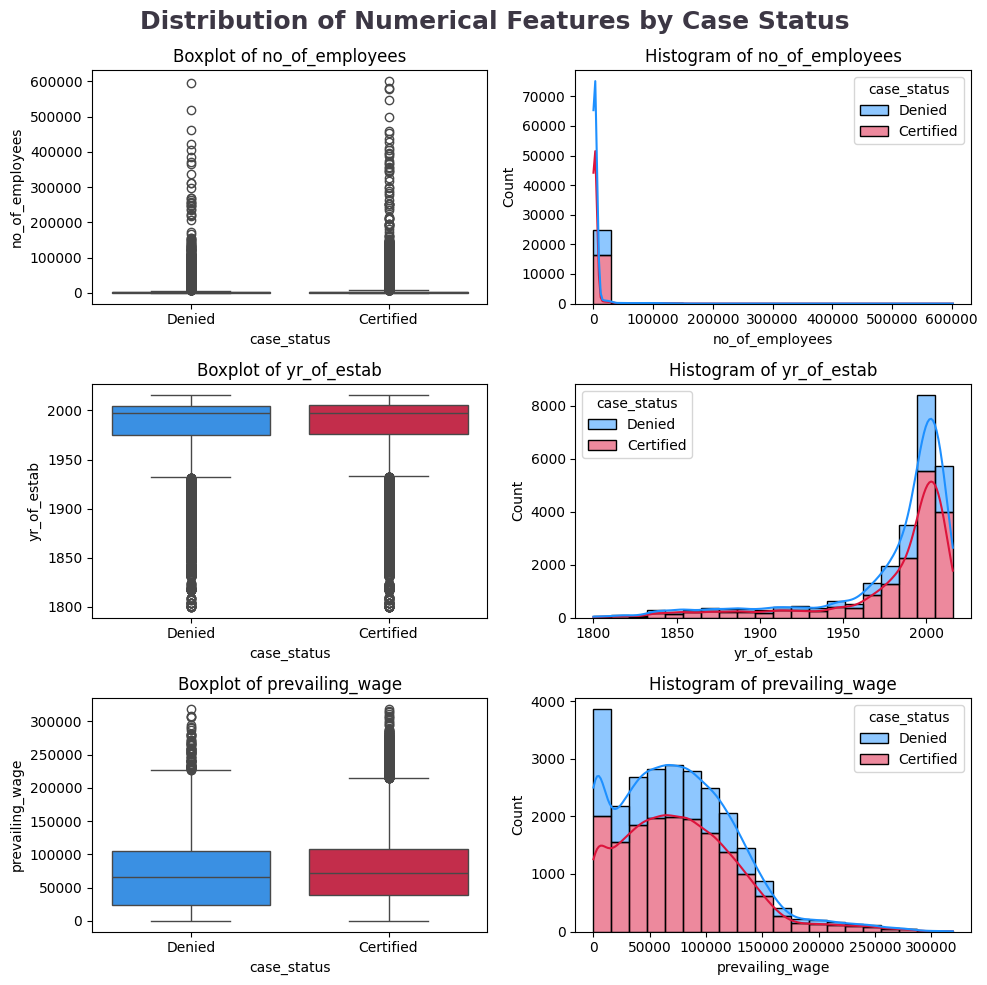

In [70]:
# Define color palette
clr1 = ['#1E90FF', '#DC143C']

# Create a figure and axes for subplots
fig, ax = plt.subplots(len(continuous_numerical_features), 2, figsize=(10,10))


fig.suptitle('Distribution of Numerical Features by Case Status', 
             color='#3C3744', fontsize=18, fontweight='bold', ha='center')


for i, col in enumerate(continuous_numerical_features):
    
    sns.boxplot(data=df, x='case_status', y=col, palette=clr1, ax=ax[i, 0])
    ax[i, 0].set_title(f'Boxplot of {col}', fontsize=12)

   
    sns.histplot(data=df, x=col, hue='case_status', bins=20, kde=True, 
                 multiple='stack', palette=clr1, ax=ax[i, 1])
    ax[i, 1].set_title(f'Histogram of {col}', fontsize=12)

fig.tight_layout()
fig.subplots_adjust(top=0.92)

# Optional: Save the plot to a file
# plt.savefig('images/multivariate_num.png')


plt.show()


## **Initial Analysis Report**

* **No of Employees** has many outliers, which can be handled in feature engineering. The `no_of_employees` feature is right-skewed.
* **`yr_of_estab`** is left-skewed, with some outliers below the lower bound of the box plot.
* **`prevailing_wage`** is right-skewed, with outliers above the upper bound of the box plot.
* There are **no missing values** in the dataset.
* The **`case_id`** column can be deleted since each row has unique values.
* The **`case_status`** column is the target variable to predict.
* In the **categorical columns**, features can be encoded into binary numerical values through feature encoding.
